# Round-2 Ergebnisse — Viewer

Dünner Viewer über die reproduzierbaren Artefakte aus `scripts/round2/score_ladder.py` und `scripts/round2/make_summary.py`.
**Hauptzahlen = DBSCAN-bereinigt** (Variante `clean`), `raw` als Robustheits-Companion.

Regenerieren: `synthre/bin/python scripts/round2/score_ladder.py && synthre/bin/python scripts/round2/make_summary.py`

In [1]:
import os
import pandas as pd
from IPython.display import Image, display

while not os.path.basename(os.getcwd()) == 'synthetic_re_data_generation':
    os.chdir('..')
SUM = 'results/round2/summary'
FIG = 'figs/round2/summary'
pd.set_option('display.width', 160)

## Sprossen-Übersicht (Mediane über 13 Parks, clean | raw)

In [2]:
overview = pd.read_csv(f'{SUM}/rung_overview.csv')
overview

,experiment,r2_clean,absERdev_clean,W1_clean,n_parks_clean,r2_raw,absERdev_raw,W1_raw,n_parks_raw
0,K1,0.7622,0.1788,0.0399,13,0.5651,0.1838,0.0495,13
1,K3,0.7164,0.1371,0.0422,13,0.4997,0.1723,0.0366,13
2,K5,0.7511,0.1069,0.0364,13,0.5378,0.1210,0.0432,13
3,M1,0.6494,0.2314,0.0631,13,0.5561,0.2816,0.0694,13
4,M2,0.6211,0.2737,0.0700,13,0.5251,0.2856,0.0694,13
5,M2noage,0.6177,0.2737,0.0757,13,0.5185,0.3045,0.0795,13
6,M3,0.6674,0.2407,0.0559,13,0.5090,0.2509,0.0635,13
7,M3allconst,0.7139,0.1580,0.0505,13,0.5287,0.2002,0.0565,13
8,M3noage,0.6477,0.2516,0.0741,13,0.4861,0.2795,0.0812,13
9,M4,0.6674,0.2516,0.0633,13,0.5011,0.2711,0.0678,13


## Kontraste — die vier Kernaussagen

Leave-one-out an der Vollkette (`M5all` bzw. `K5`) + inkrementelle Companions.
`abs_er_dev_median_diff < 0` und `improves=True` ⇒ Komponente reduziert den Energie-Bias.
p-Werte: exakter Wilcoxon (N=13), Holm-korrigiert über die 4 Hauptkontraste.

In [ ]:
contrasts = pd.read_csv(f'{SUM}/contrasts.csv')
cc = contrasts[contrasts.variant == 'clean']
cols = ['contrast', 'a', 'b', 'abs_er_dev_median_diff', 'abs_er_dev_p',
        'abs_er_dev_p_holm', 'abs_er_dev_rank_biserial', 'abs_er_dev_ci',
        'r2_median_diff', 'r2_p', 'improves']
cc[cols].round(4)

In [ ]:
# Wilcoxon-Zusammenfassung im Stil der bisherigen Auswertung
for _, r in cc.iterrows():
    verdict = 'VERBESSERT' if r['improves'] else 'kein Gewinn'
    holm = f" (Holm: {r['abs_er_dev_p_holm']:.4f})" if pd.notna(r.get('abs_er_dev_p_holm')) else ''
    print(f"{r['contrast']:<28} {r['b']:>11} → {r['a']:<11} "
          f"Δ|ER−1| = {r['abs_er_dev_median_diff']:+.4f}  p = {r['abs_er_dev_p']:.4f}{holm}  → {verdict}")

## Effekt-Matrix: welche Komponente hilft in welchem Park

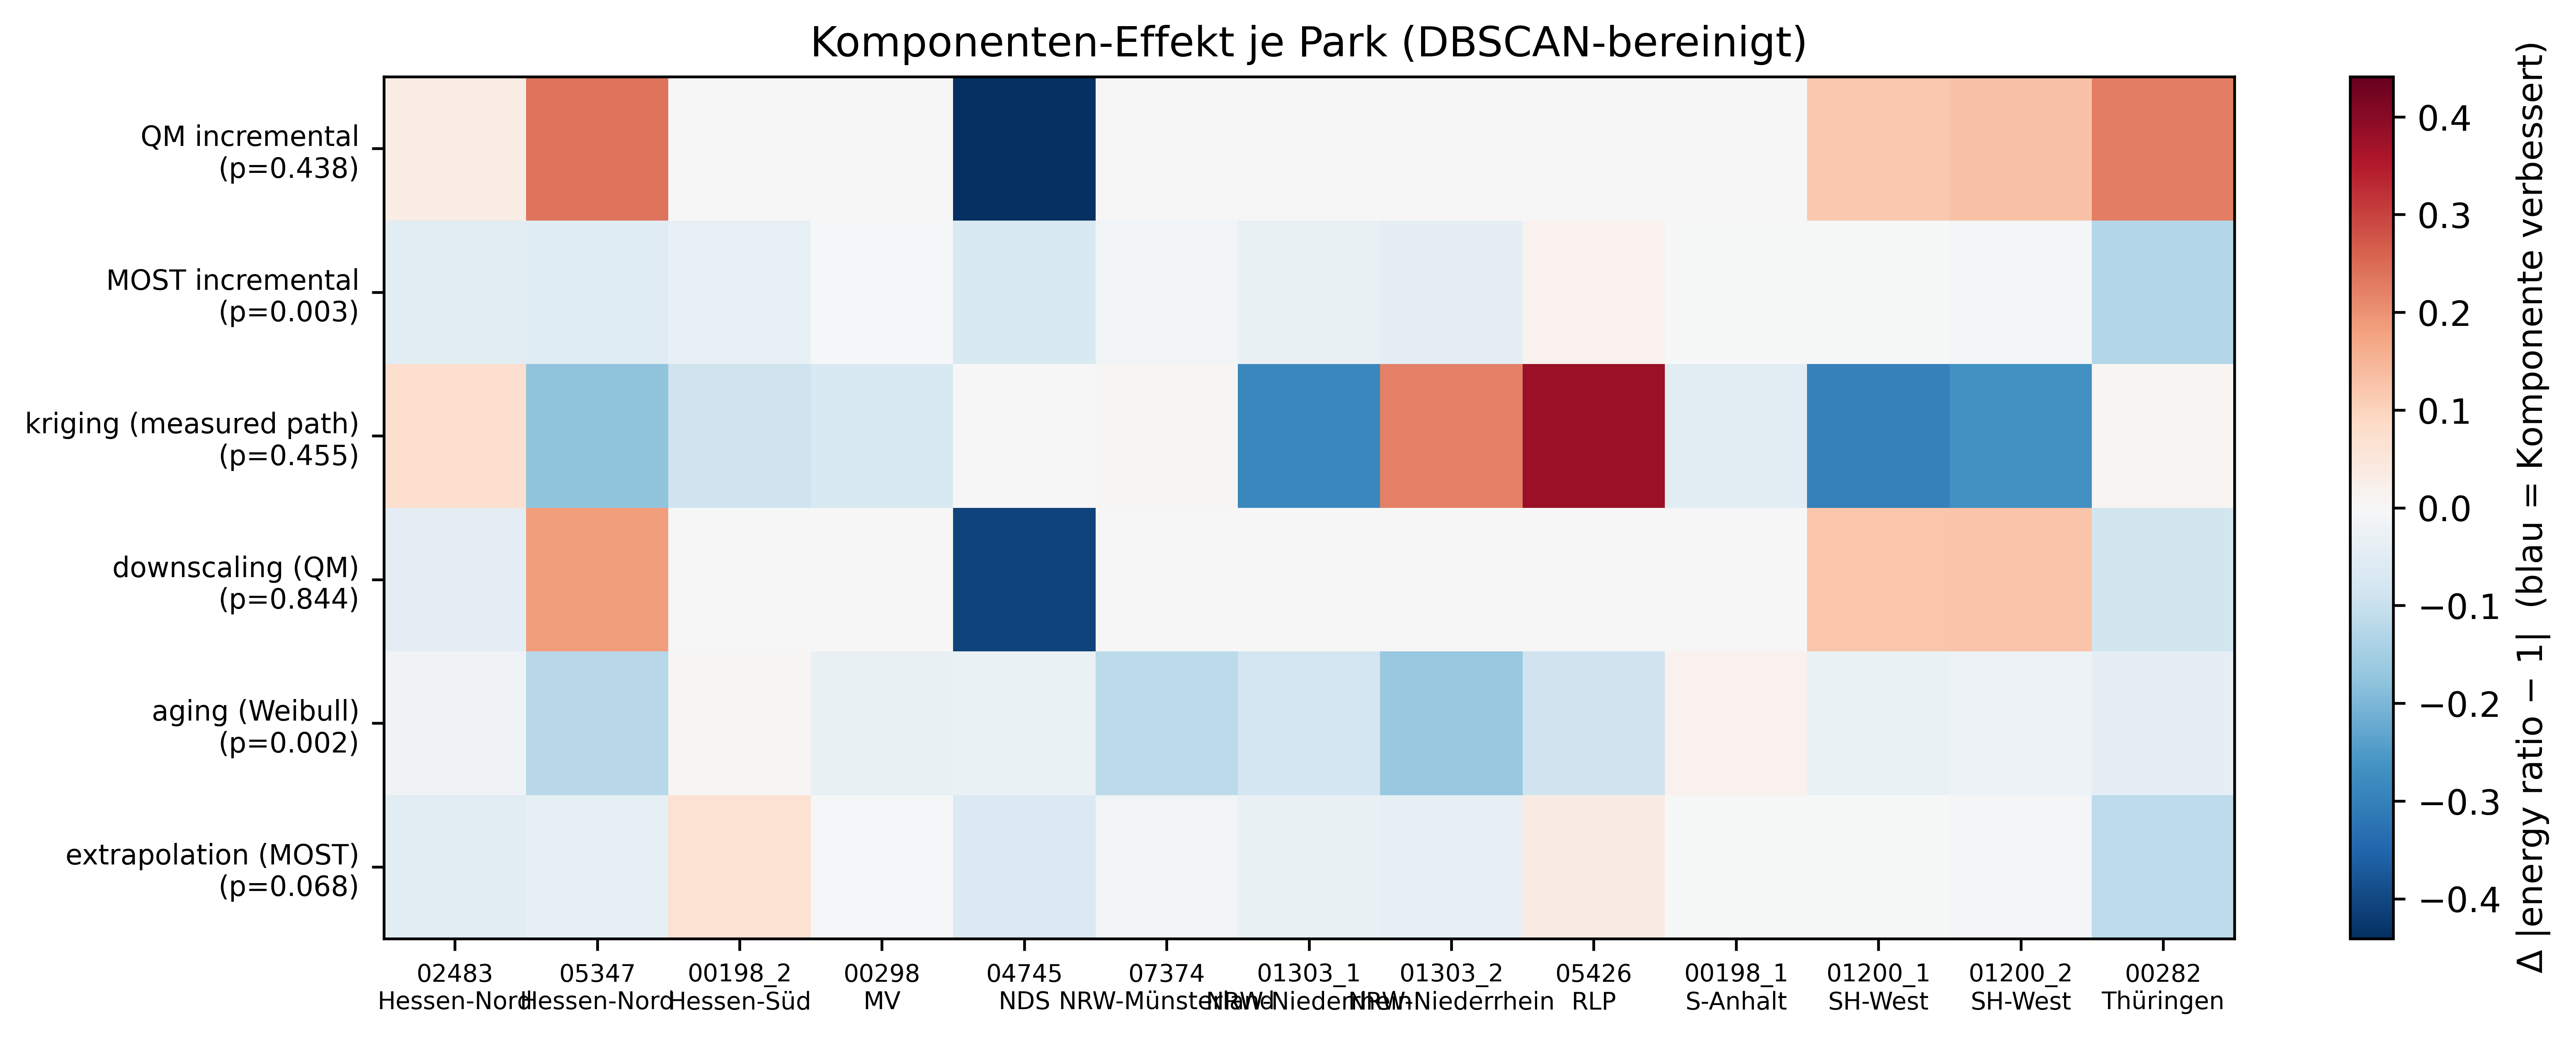

In [5]:
display(Image(f'{FIG}/effect_matrix.png', width=1100))

## Ladder: ERA5-Pfad (M) und Messwind-Pfad (K)

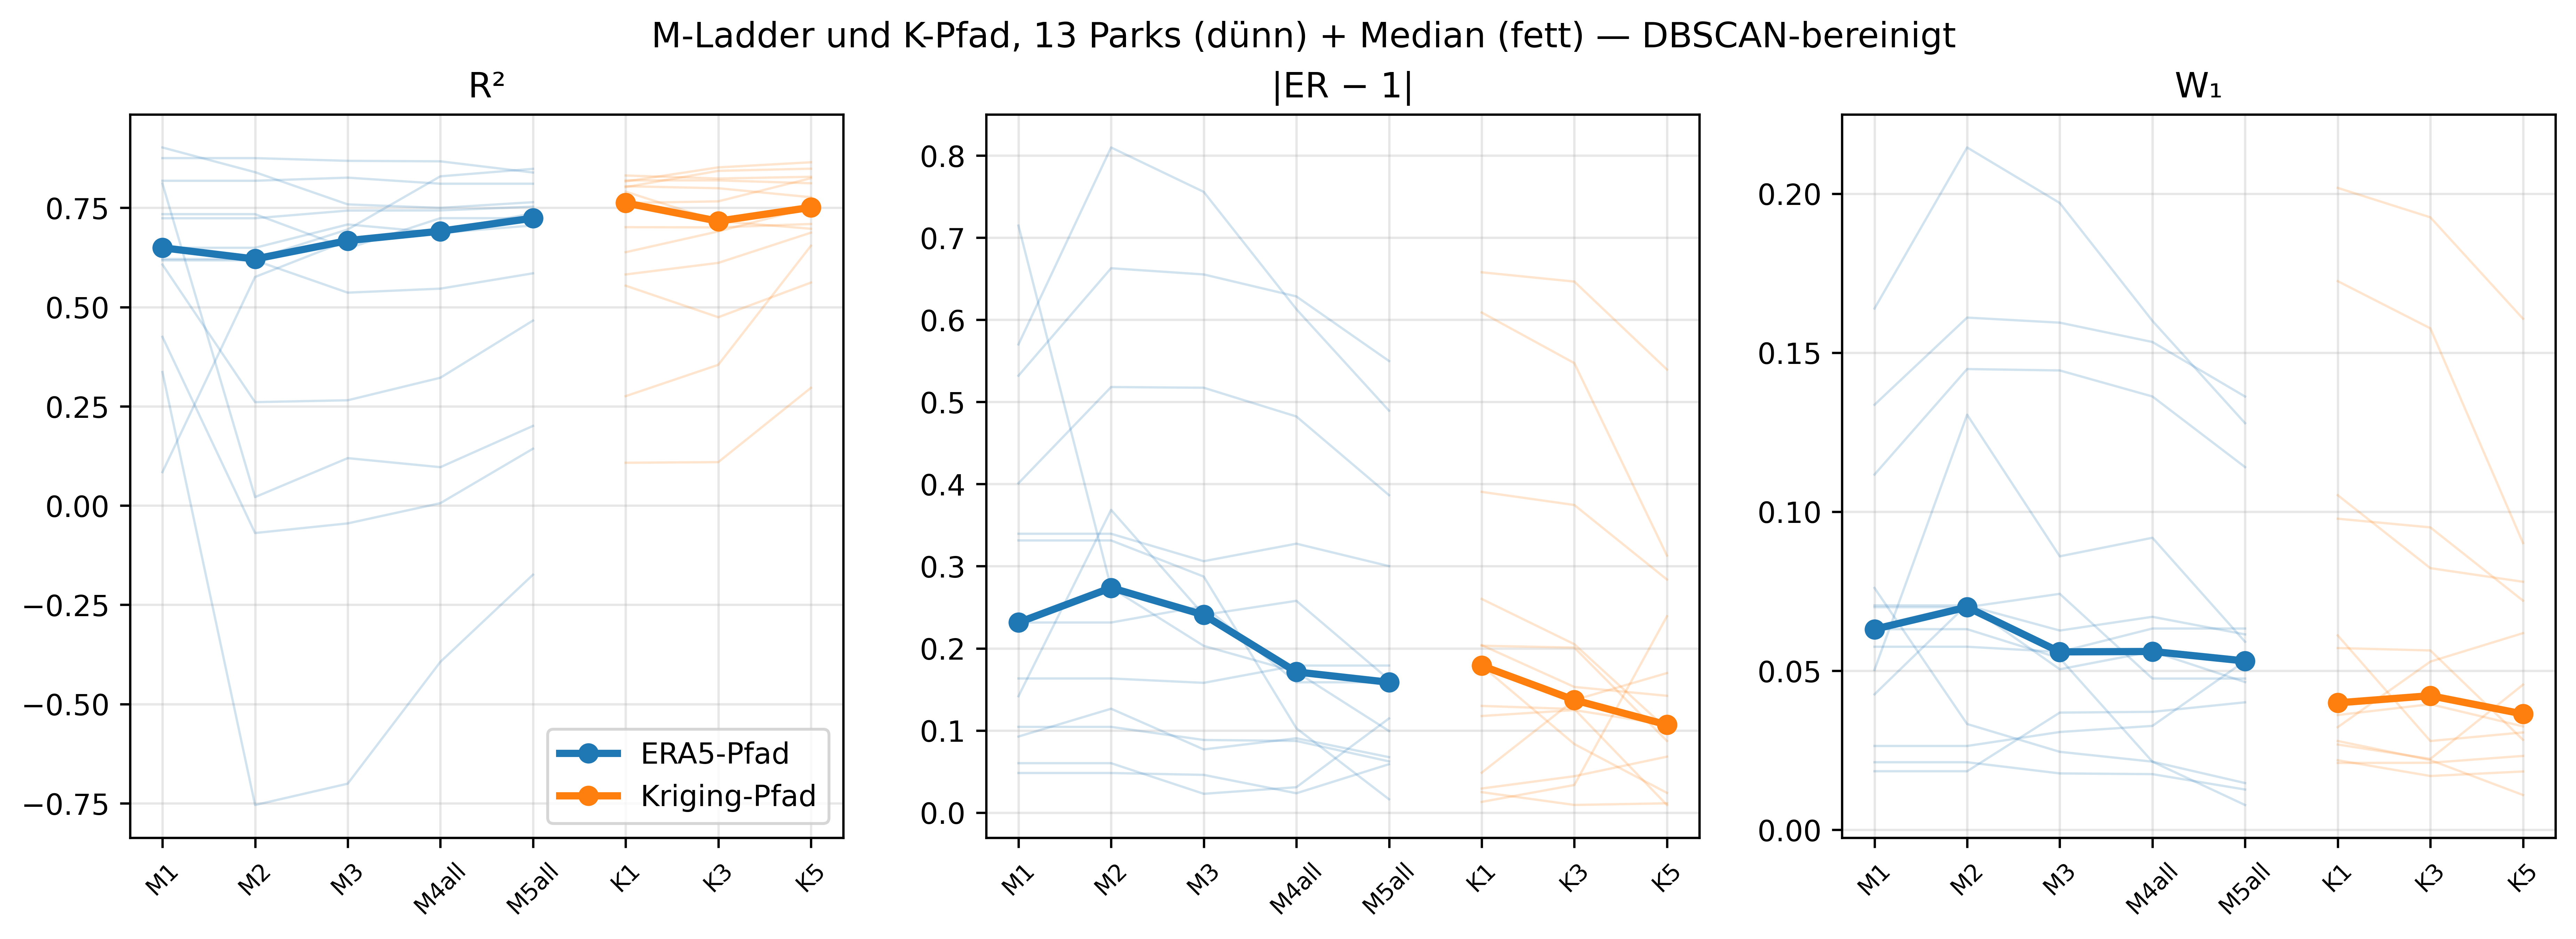

In [6]:
display(Image(f'{FIG}/ladder_spaghetti.png', width=1100))

## Leave-one-out-Dumbbells (Vollkette)

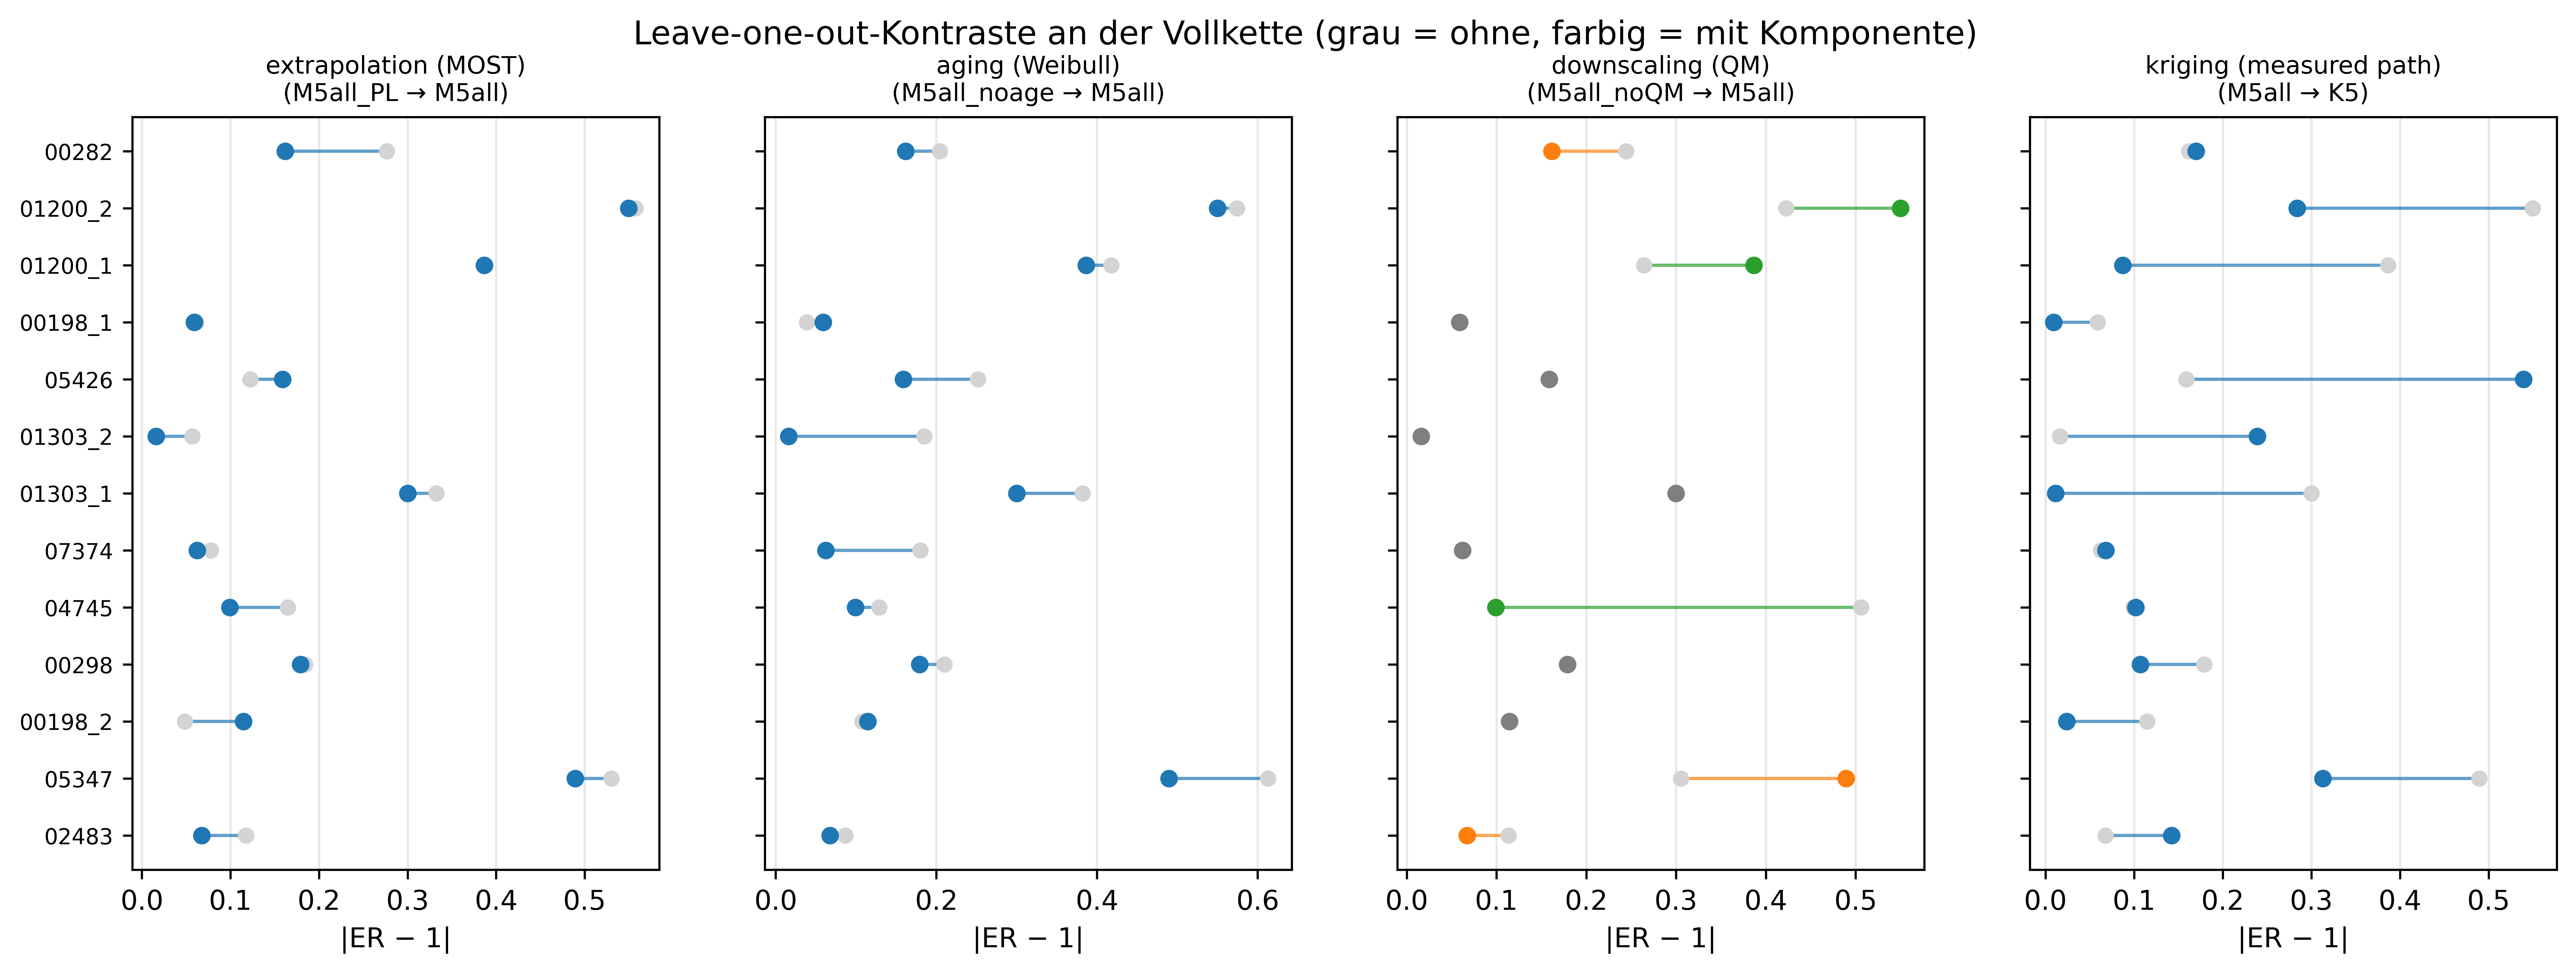

In [7]:
display(Image(f'{FIG}/dumbbells_headline.png', width=1100))

## Aging: Bias vs. Alter (WP4-Validierung, Parameter literaturverankert)

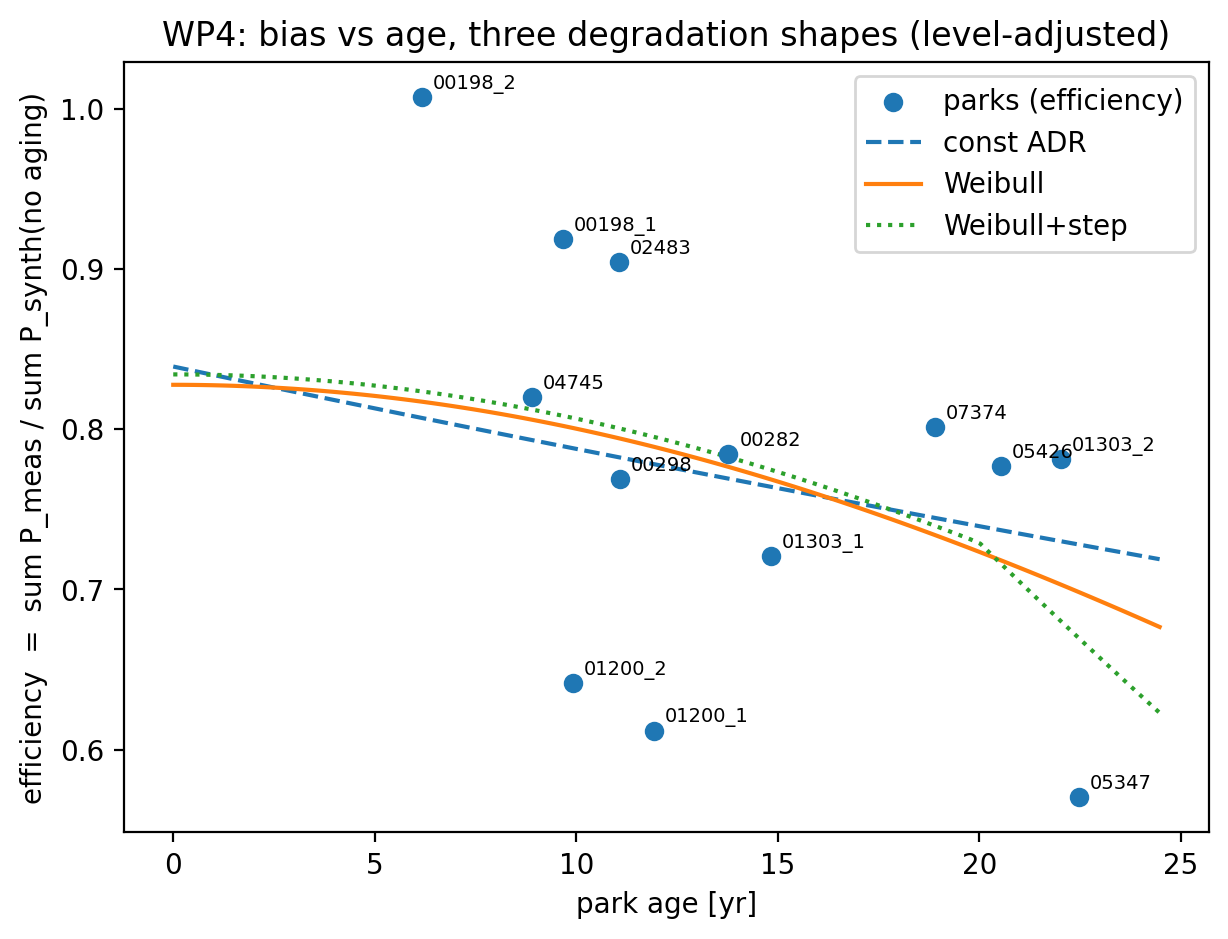

In [8]:
display(Image('figs/round2/bias_vs_age.png', width=700))

## Bar-Grids je Park (Stil der bisherigen Auswertung)

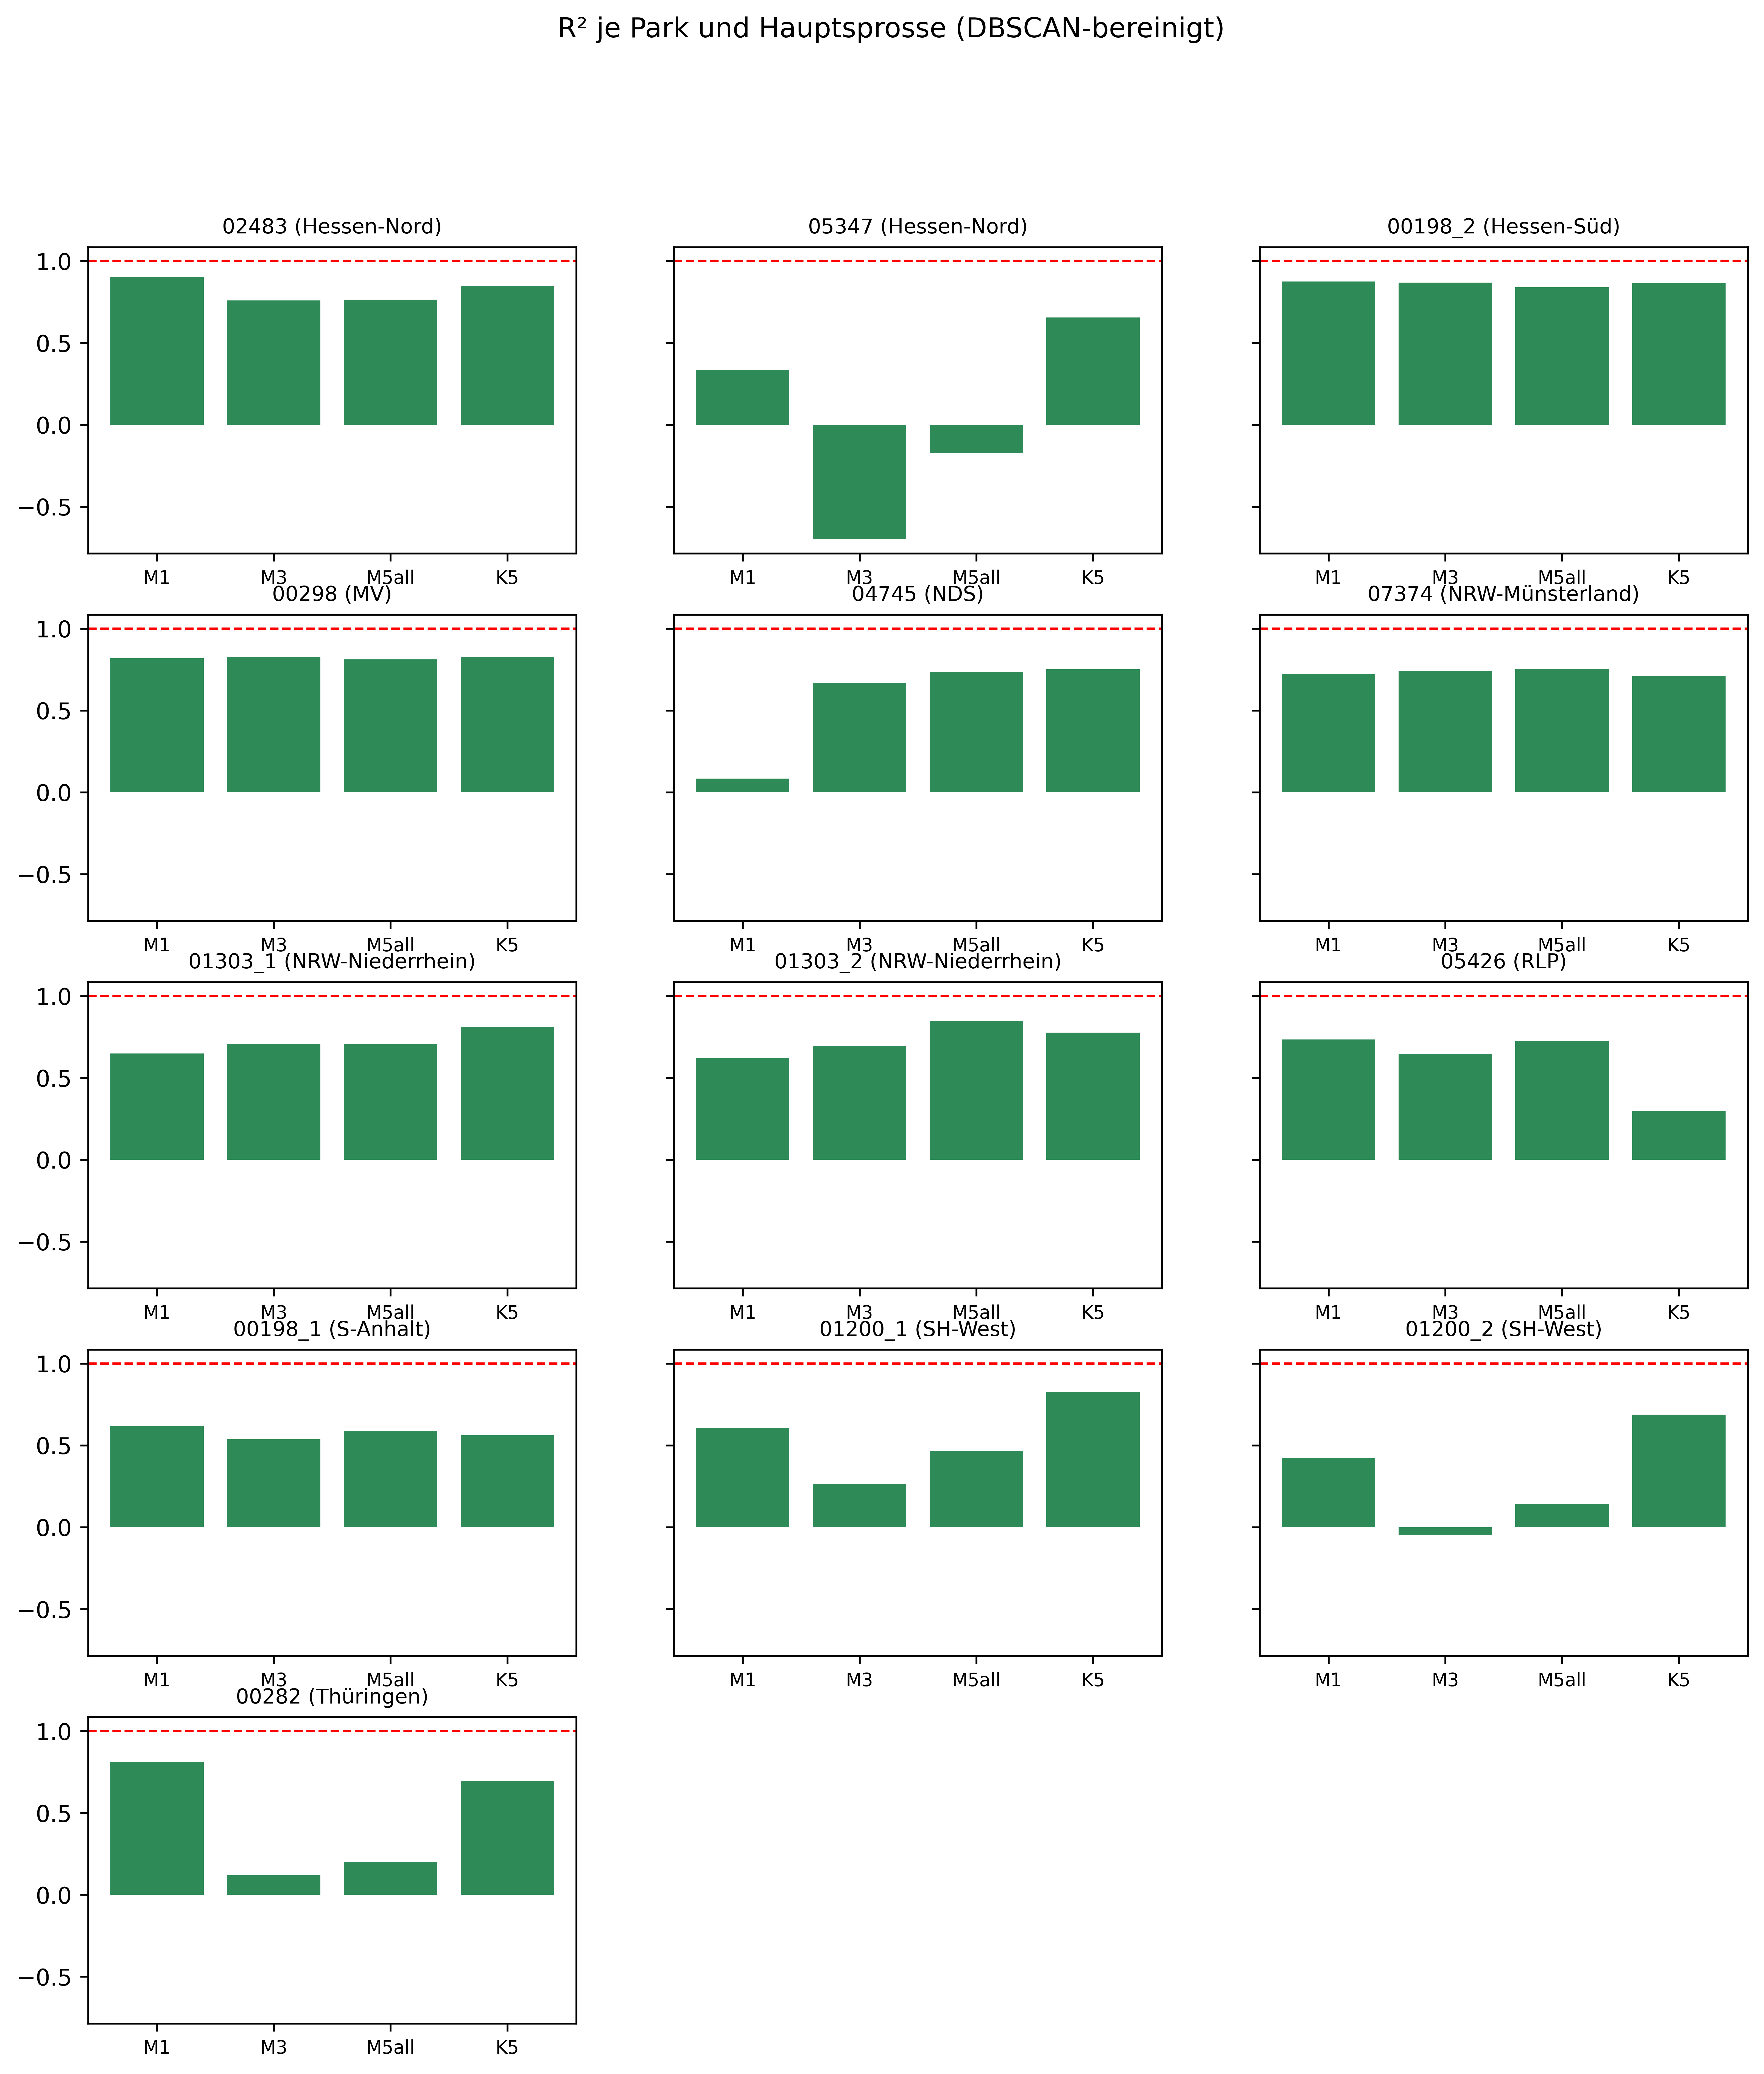

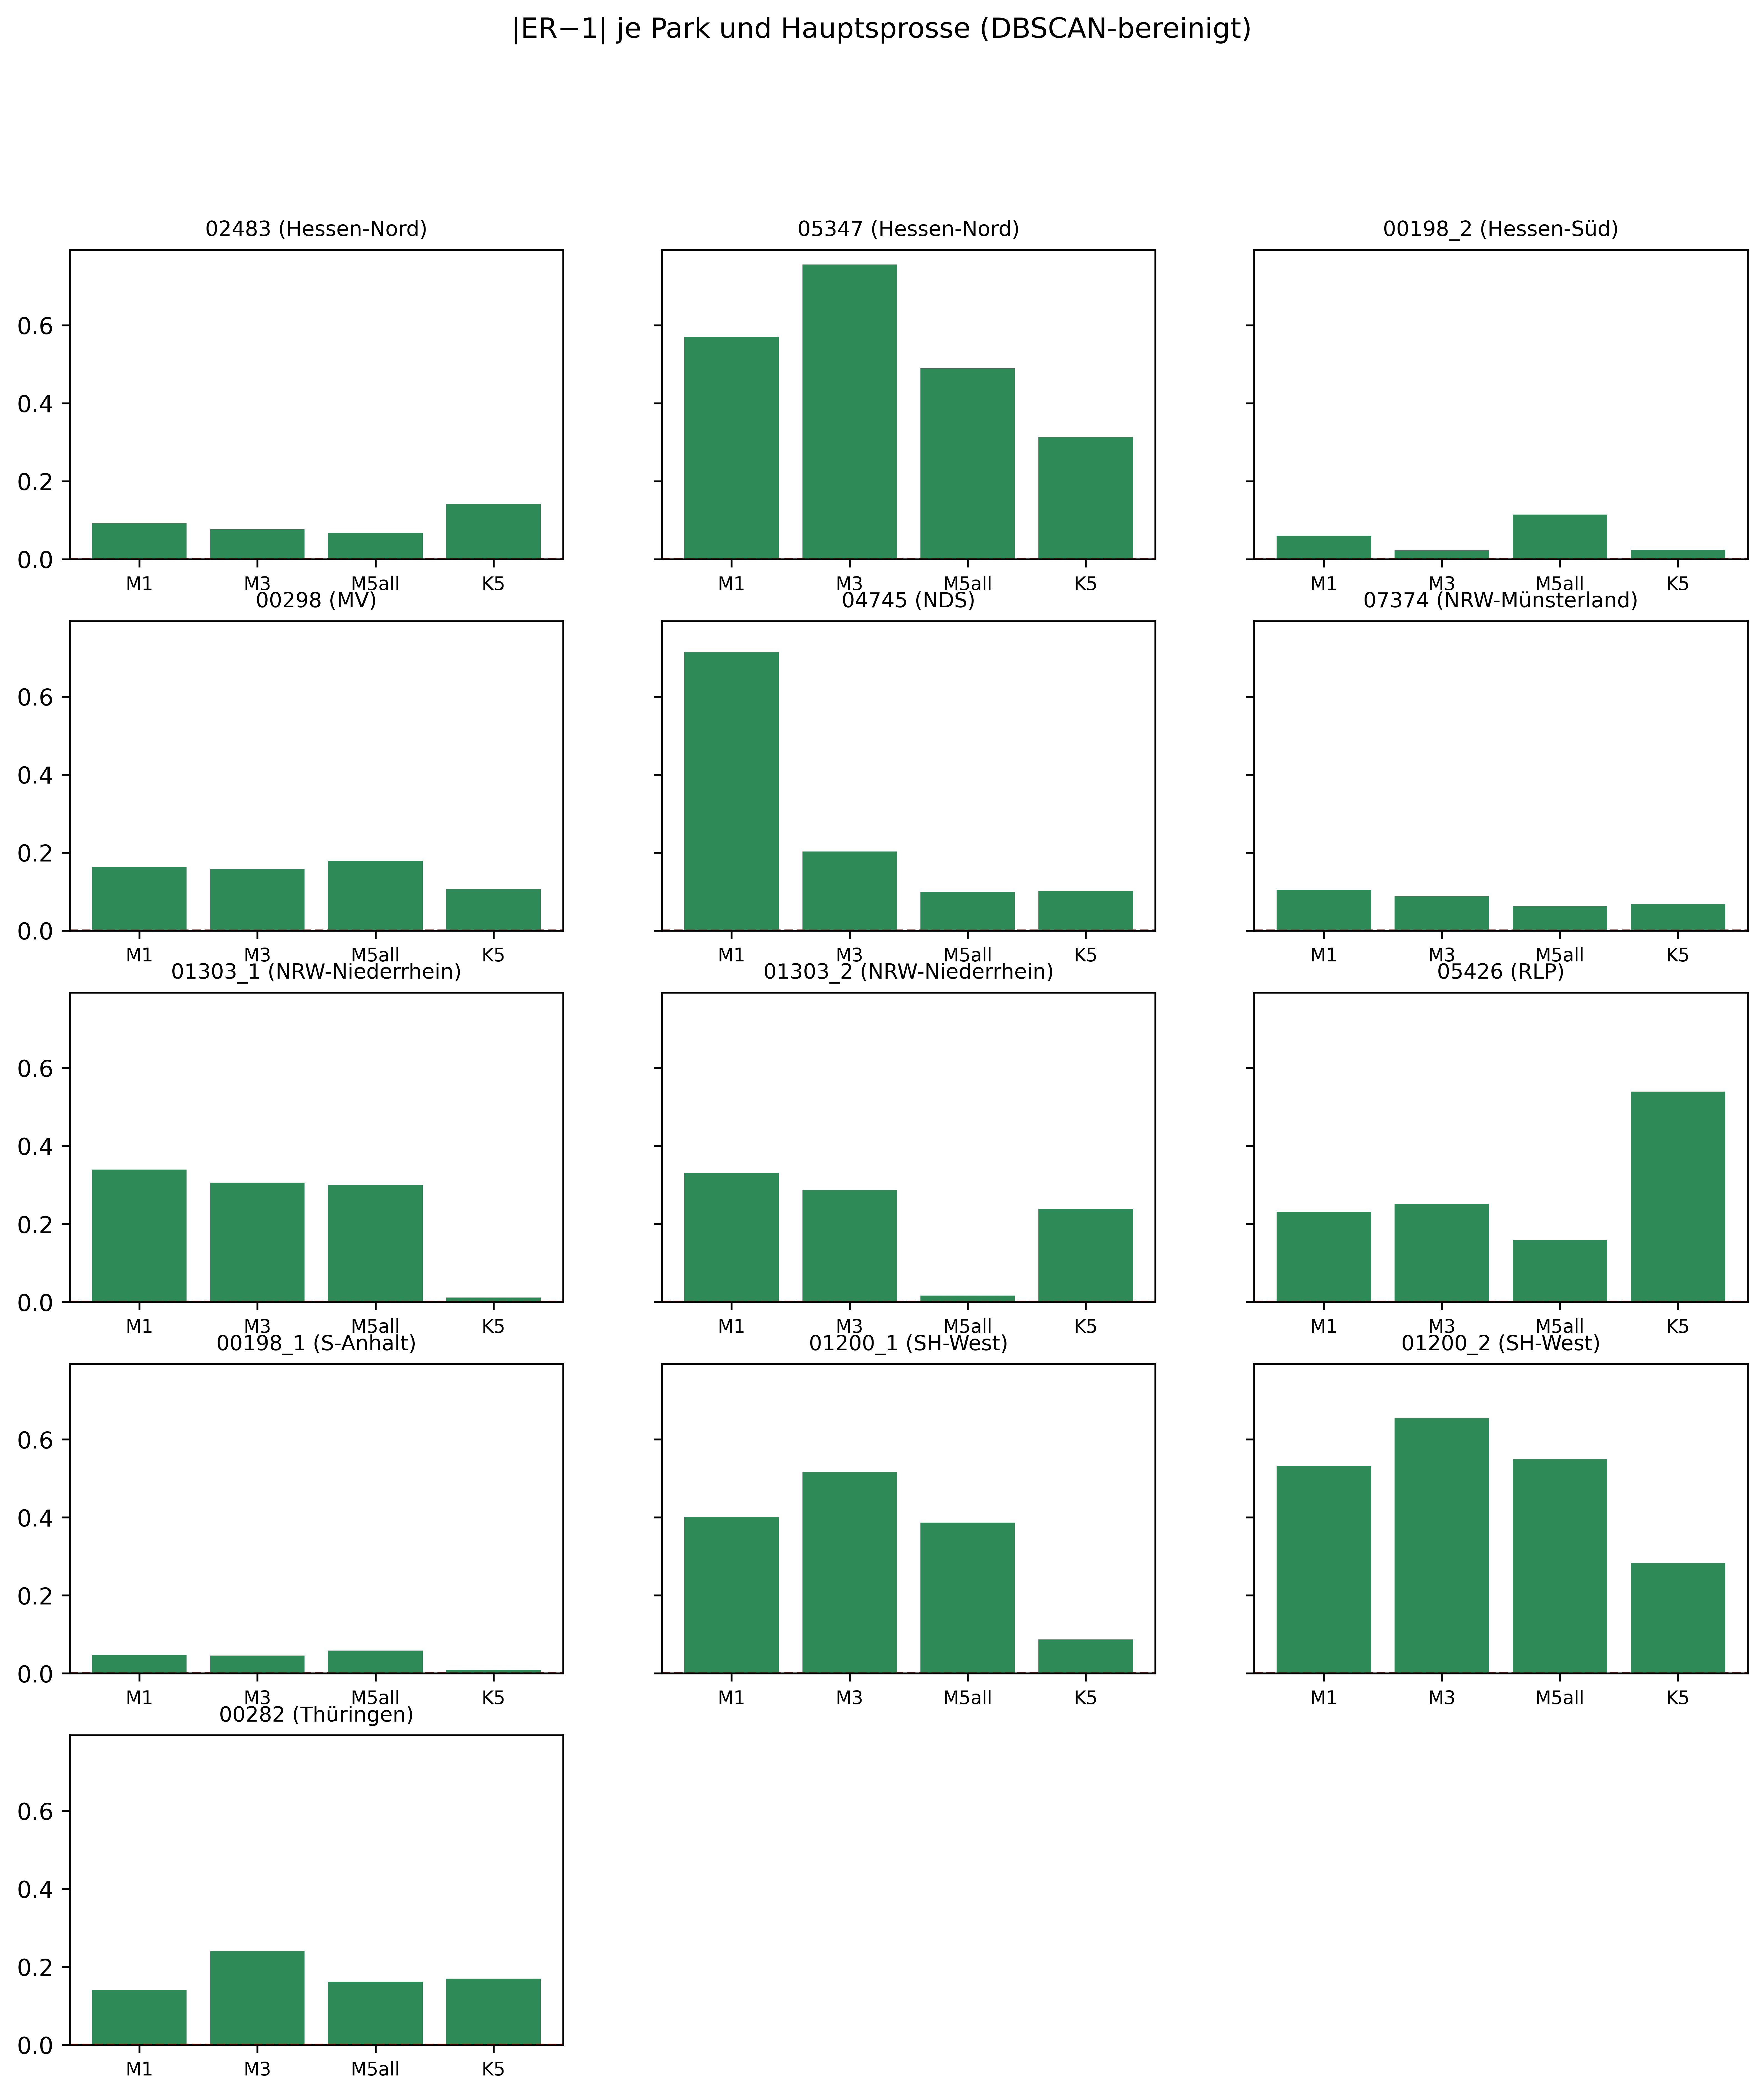

In [10]:
display(Image(f'{FIG}/bars_r2.png', width=1000))
display(Image(f'{FIG}/bars_abs_er_dev.png', width=1000))

## Ausreißeranteile pro Modell × Park (Transparenz der per-Modell-Masken)

In [11]:
shares = pd.read_csv(f'{SUM}/outlier_shares.csv', index_col=0)
shares.style.background_gradient(cmap='Reds', vmin=0, vmax=0.2).format('{:.1%}')

,K1,K3,K5,M1,M2,M2noage,M3,M3allconst,M3noage,M4,M4all,M4b,M4ball,M5,M5all,M5all_PL,M5all_noQM,M5all_noage
park_id,,,,,,,,,,,,,,,,,,
00198_1,11.5%,11.5%,11.5%,9.8%,9.8%,9.8%,9.6%,9.6%,9.6%,9.6%,9.6%,9.6%,9.6%,9.6%,9.6%,9.8%,9.6%,9.6%
00198_2,22.0%,25.1%,25.1%,18.0%,18.0%,18.0%,20.8%,20.8%,20.8%,20.8%,20.8%,20.8%,20.8%,20.8%,20.8%,18.0%,20.8%,20.8%
00282,17.6%,18.2%,18.2%,15.4%,17.8%,17.8%,17.9%,17.9%,17.9%,17.9%,17.9%,17.9%,17.9%,17.9%,17.9%,17.8%,15.0%,17.9%
00298,21.1%,20.9%,20.9%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%,17.0%
01200_1,13.1%,13.4%,13.4%,12.6%,12.4%,12.4%,12.4%,12.4%,12.4%,12.4%,12.4%,12.4%,12.4%,12.4%,12.4%,12.4%,12.7%,12.4%
01200_2,14.0%,13.5%,13.5%,13.3%,13.8%,13.8%,13.6%,13.6%,13.6%,13.6%,13.6%,13.6%,13.6%,13.6%,13.6%,13.8%,14.0%,13.6%
01303_1,6.0%,6.5%,6.5%,5.9%,5.9%,5.9%,6.6%,6.6%,6.6%,6.6%,6.6%,6.6%,6.6%,6.6%,6.6%,5.9%,6.6%,6.6%
01303_2,7.5%,8.2%,8.2%,7.9%,7.9%,7.9%,8.0%,8.0%,8.0%,8.0%,8.0%,8.0%,8.0%,8.0%,8.0%,7.9%,8.0%,8.0%
02483,18.1%,20.1%,20.1%,17.7%,16.5%,16.5%,16.1%,16.1%,16.1%,16.1%,16.1%,16.1%,16.1%,16.1%,16.1%,16.5%,18.7%,16.1%
